## Step 1: Collection, Cleaning and Storage of Data

In this first step I am going to perform folllowing tasks:

- I import the required Python libraries and packages(eg. pandas, numpy, matplotlib, seaborn, etc.) to do data analytics.
- I download the Football Matches data of the English Premier League 2015/16 Season from an online JSON file.
- Then I convert the raw JSON file data into a clean pandas DataFrame.
- After that I create useful additional columns like total number of goals, difference of goals, and total points scored by both  home and away teams.
- Then I save the final dataset to a CSV file, which can be used later.
- I have taken the match data from the openfootball project on GitHub, using the 2015–16 English Premier League JSON file. The cleaned data is saved locally as `SDPA_part2_premier_league_2015_16_matches.csv`after all the processing.
- I have even checked the dataset for missing values and outliers, and I can confirm that the dataset is complete and sensible.
- The data is crawled from the openfootball project on GitHub. The final dataset contains 380 rows (one row for each match) and 5 columns, which includes date of the match, home team name, away team name, number of goals scored by home team and number of goals scored by away team. These variables allow us to analyse how various teams score and perform during a season.

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression

# Set the visual style 
sns.set_style("whitegrid")

# Load the Data (2015-16 English Premier League) 
url = "https://raw.githubusercontent.com/openfootball/football.json/master/2015-16/en.1.json"
response = requests.get(url)
data = response.json()

# Data Parsing
rows = []
for m in data["matches"]:
    score = m.get("score", {})
    ft = score.get("ft", [None, None])
    
    # Only process matches that have been played
    if ft[0] is not None:
        rows.append({
            "date": m.get("date"),
            "home_team": m.get("team1"),
            "away_team": m.get("team2"),
            "home_goals": ft[0],
            "away_goals": ft[1]
        })

df = pd.DataFrame(rows)
# Store the dataset as a CSV file (can be used later)
df.to_csv("SDPA_part2_premier_league_2015_16_matches.csv", index=False)

print("CSV file saved successfully!")

df["date"] = pd.to_datetime(df["date"])

# Calculate total number of goals for a given match
df["total_goals"] = df["home_goals"] + df["away_goals"]

# Calculate difference of goals for a given match
df["goal_diff"] = df["home_goals"] - df["away_goals"]

# Check for missing values in the dataset
missing_table = df.isna().sum().reset_index()
missing_table.columns = ["Column", "Missing Values"]

print("Missing Values Summary:")
display(missing_table)


# Represent Descriptive Statistics for key variables
stats_table = df[["home_goals", "away_goals", "total_goals", "goal_diff"]].describe()

print("Descriptive Statistics for Key Numerical Variables:")
display(stats_table.round(2))


CSV file saved successfully!
Missing Values Summary:


,Column,Missing Values
0,date,0
1,home_team,0
2,away_team,0
3,home_goals,0
4,away_goals,0
5,total_goals,0
6,goal_diff,0


Descriptive Statistics for Key Numerical Variables:


,home_goals,away_goals,total_goals,goal_diff
count,380.00,380.00,380.00,380.00
mean,1.49,1.21,2.70,0.28
std,1.26,1.15,1.68,1.72
min,0.00,0.00,0.00,-6.00
25%,1.00,0.00,1.00,-1.00
50%,1.00,1.00,3.00,0.00
75%,2.00,2.00,4.00,1.00
max,6.00,6.00,9.00,5.00


This information confirms that this data set has complete and realistic data for football scores and will be appropriate for exploratory analysis with no additional clean-up or transform requirements.

### Data Cleaning Summary (Step 1)

**Missing Values:**  
The `df.isna().sum()` command shows **0 missing values in each of the column**, confirming that the dataset is complete and **no imputation were needed**.

**Outliers:**  
The `describe()` indicates that:
- The home team and visiting team's goal values ranged from **0 to 6**
- Total Goals scored by both teams at a game ranged from **0 to 9**

All of these values are completely normal for soccer match outcomes, so **no matches were removed** as outliers.

**Methodology Justification:**

Because the entire data set contained complete data there was no need for imputation. In addition, because the all of the score values were normal and valid soccer match outcomes no matches were removed from the data set as outliers.

No imputation was used because all of the variable entries were present. Also, our outlier inspection confirmed that all score values were valid football results; therefore, we did not remove any games mathces from our sample.

In [19]:

# This function defines result of the match and assigns home points and away points
def get_result_data(row):
    """
    
    Given a row of match data which includes match date, home team name, away team name,
    home team goals, away team goals, total goals and goal difference
    return a tuble (match result,home_points , away_points)

    - "Home Team Win" gives (3, 0)
    - "Away Team Win" gives (0, 3)
    - "Draw" gives (1, 1)

    """

    if row["home_goals"] > row["away_goals"]:
        return ("Home Win", 3, 0)
    elif row["home_goals"] < row["away_goals"]:
        return ("Away Win", 0, 3)
    else:
        return ("Draw", 1, 1)

# Use the function and create 3 new columns
df[['result', 'home_points', 'away_points']] = df.apply(
    lambda x: pd.Series(get_result_data(x)), axis=1
)

print(f"Data Loaded: {df.shape[0]} matches.")
display(df.head())


Data Loaded: 380 matches.


,date,home_team,away_team,home_goals,away_goals,total_goals,goal_diff,result,home_points,away_points
0,2015-08-08,Manchester United,Tottenham Hotspur,1,0,1,1,Home Win,3,0
1,2015-08-08,AFC Bournemouth,Aston Villa,0,1,1,-1,Away Win,0,3
2,2015-08-08,Everton FC,Watford FC,2,2,4,0,Draw,1,1
3,2015-08-08,Leicester City,Sunderland AFC,4,2,6,2,Home Win,3,0
4,2015-08-08,Norwich City,Crystal Palace,1,3,4,-2,Away Win,0,3


With the clean and engineered data in hand, we now begin exploratory data analysis (Step 2).

## Step 2: Exploratory Data Analysis (EDA)

We will graphically investigate our data to answer some questions about it:

- Histograms to find how many home and away goals were scored per game.
- A box plot of goal difference to find how often the home team won by a specific margin.
- A correlation matrix to determine how the numerical variables (home goals, away goals, total goals, and goal difference) relate to each other.

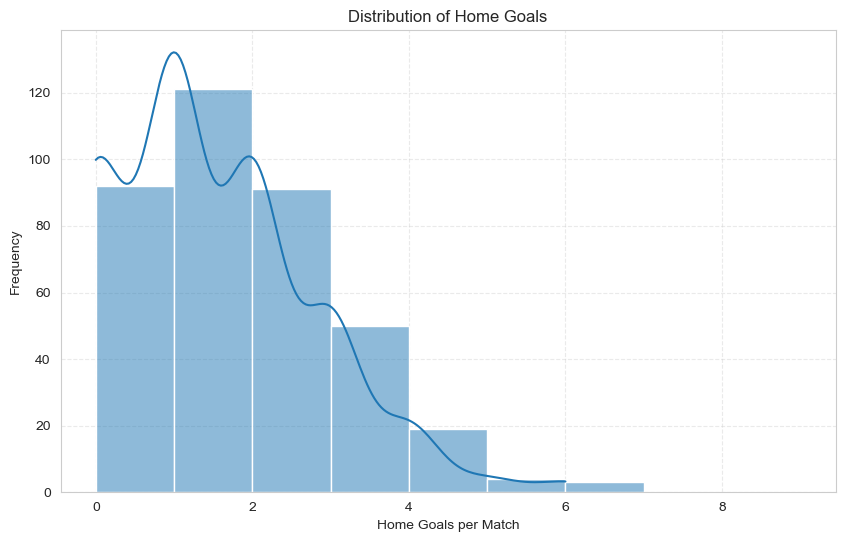

In [20]:
# 1. Distribution of Home Goals (Histogram)

plt.figure(figsize=(10, 6))
sns.histplot(df["home_goals"], bins=range(0, 10), kde=True)
plt.xlabel("Home Goals per Match")
plt.ylabel("Frequency")
plt.title("Distribution of Home Goals")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


### Interpretation (Home Goals distribution)

- Most **home teams** have between **0 and 2 goals per game**, as seen in the histogram. Therefore, the distribution is skewed to the right.

- A small number of games reached as high as **6 goals**; therefore, there were a few games where the home team dominated.

- This supports the notion that **playing at home is associated with higher scoring potential** for the team.

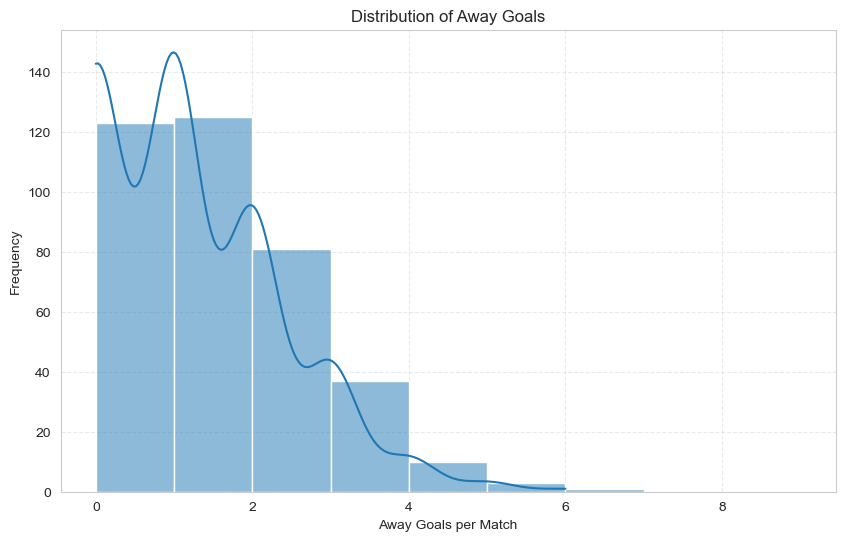

In [21]:


# 2. Distribution of Away Goals (Histogram)

plt.figure(figsize=(10, 6))
sns.histplot(df["away_goals"], bins=range(0, 10), kde=True)
plt.xlabel("Away Goals per Match")
plt.ylabel("Frequency")
plt.title("Distribution of Away Goals")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

### Interpretation (Away Goals Distribution)

- The majority of away goals fall into **0-1 goals  per game**,indicating lower scoring in away games.

- There are very fewer games with more than **4 away goals**,

- The distribution of **away goals** appears to be **compressed** compared to the distribution of home goals. This visually reinforces the idea of a **home advantage**.

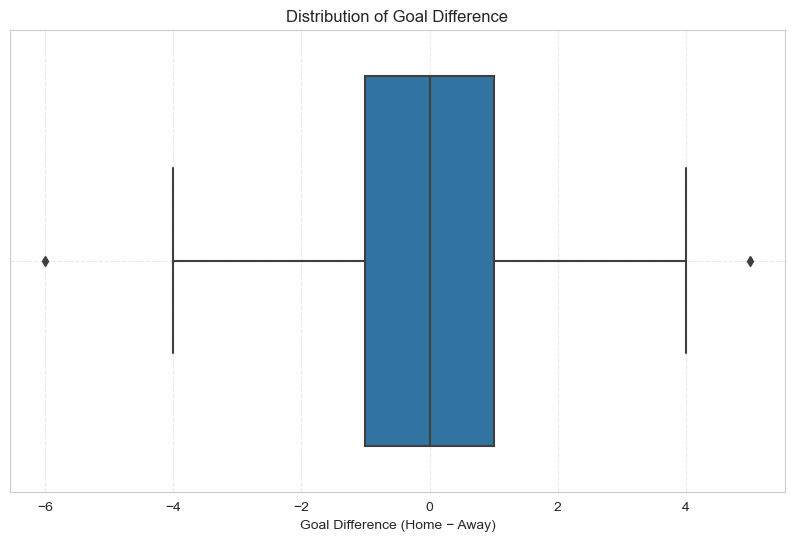

In [22]:


# 3. Distribution of Goal Difference (Box Plot)

plt.figure(figsize=(10, 6))
sns.boxplot(x=df["goal_diff"])
plt.xlabel("Goal Difference (Home − Away)")
plt.title("Distribution of Goal Difference")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

### Interpretation (Goal Difference - Boxplot)

- The **median goal difference is slightly greater than 0**, which means that **home teams win more games** than they lose.

- There is a **long negative tail** in the distribution that represents **rare instances of heavy away wins**.

- However, since the bulk of the **distribution still leans towards the home team's favor**, we can say that there is direct graphical evidence of a **home advantage**.

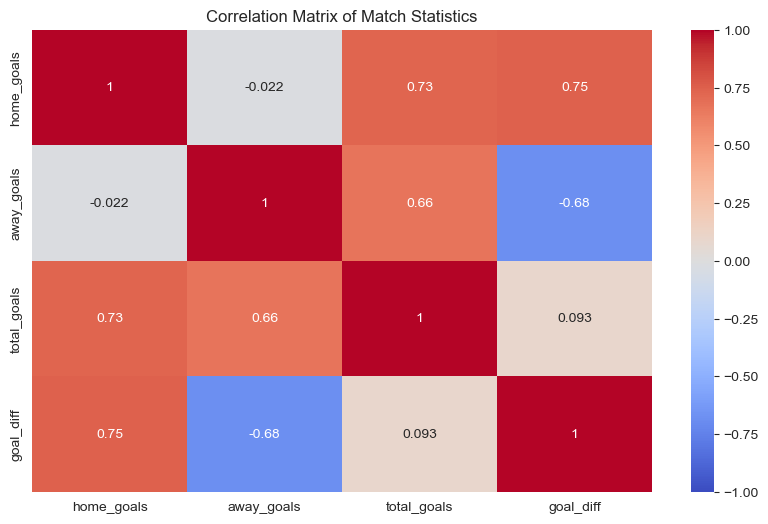

In [23]:


# 4. Correlation Matrix (Heatmap)

plt.figure(figsize=(10, 6))
corr_matrix = df[["home_goals", "away_goals", "total_goals", "goal_diff"]].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Match Statistics")
plt.show()

### Interpretation (Correlation Matrix)

- Total goals show a **strong positive correlation** with:
- Total goals are **positively correlated** with:

  - Home goals (**0.73**)
  - Away goals (**0.66**)

- There is **almost no correlation** between the number of home and away goals **(-0.02)**; so teams tend to score **independently** of each other.

We also know that away goals **correlate negatively with goal difference (-0.68)**, which makes sense mathematically given the definition of goal difference.

In [24]:

# 5. Additional EDA : Top 5 Teams by Average home Goal difference

avg_goal_diff_home = (
    df.groupby("home_team")["goal_diff"]
      .mean()
      .sort_values(ascending=False)
      .head(5)
      .reset_index()                     
)

# Rename columns for a clean table
avg_goal_diff_home.columns = ["Team", "Average Home Goal Difference"]

# Rounding values 
avg_goal_diff_home["Average Home Goal Difference"] = (
    avg_goal_diff_home["Average Home Goal Difference"].round(2)
)

# Assign rank 
avg_goal_diff_home.insert(0, "Rank", range(1, len(avg_goal_diff_home) + 1))

# Display the formatted Columns
display(
    avg_goal_diff_home
        .style
        .hide(axis="index")    
        .set_caption("Top 5 Teams by Average Home Goal Difference (Home Matches Only)")
)

Rank,Team,Average Home Goal Difference
1,Manchester City,1.370000
2,Tottenham Hotspur,1.050000
3,Arsenal FC,1.050000
4,Manchester United,0.950000
5,Southampton FC,0.890000


### Interpretation of Additional EDA (Top 5 Teams by Average Home Goal Difference)

- This table lists the **ranking of the top 5 teams by their average goal difference while playing at home**.

- **Manchester City** had the largest average home goal difference (approximately **1.37**), which means they dominated at home greatly.

- The next three teams (**Tottenham Hotspur, Arsenal, and Manchester United**) also showed a significant positive home goal difference advantage.

- This further supports the existence of a **home advantage** and suggests that **stronger teams benefit disproportionately from being at home**.

## Conclusion of Step 2 (EDA)

- Most home teams typically score between **0 and 2 goals** per game with higher extreme values than away teams.

- The goal difference distribution was **slightly skewed towards the home teams**, which again supports the existence of a **home advantage**.

- As expected in match scoring, total goals are strongly positively correlated with both home and away goals.

- There was **almost no direct correlation** between home goals and away goals; which again illustrates the **independent nature of team performances**.

- In addition to the correlations, the descriptive statistics provided us with additional information. For example, the **mean of home goals (1.49**) is significantly larger than the **mean of away goals (1.21**), which reinforces the notion that home teams score more goals than away teams prior to formal hypothesis testing.


With a good understanding of the scoring patterns, goal distributions, and the inter-variable relationships based on the exploratory analysis, we now transition to using the match-level point data to recreate the final league table in Step 3.

## Step 3: Final League Table Reconstruction

Here we used the match-level data to create the final league table:

- Add up all of the points gained by winning at home for each team.
- Add up all of the points gained by winning away for each team.
- Combine the home and away points to generate the total points for each team.
- Sort the teams by total points to confirm who the champion is and to compare the top and bottom teams.

--- Final 2015-16 Premier League Standings (Reconstructed) ---


,Team,Total Points
1,Leicester City,81
2,Arsenal FC,71
3,Tottenham Hotspur,70
4,Manchester City,66
5,Manchester United,66


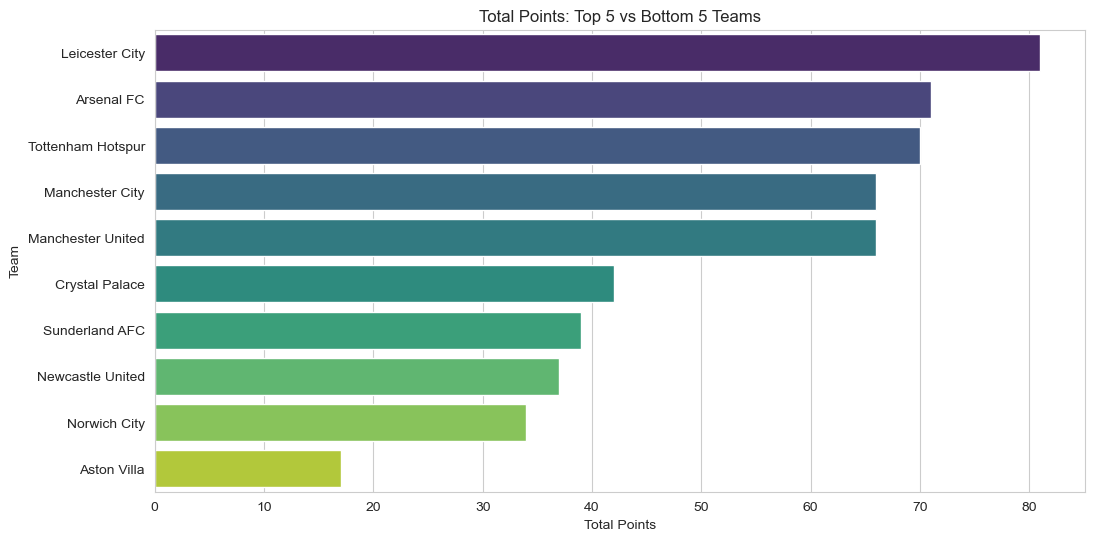

In [25]:
# Final League Table Reconstruction

# 1. Add up all the points team earned at home
home_stats = df.groupby("home_team")["home_points"].sum().reset_index()
home_stats.rename(columns={"home_team": "team", "home_points": "points"}, inplace=True)

# 2. Add up all the away points
away_stats = df.groupby("away_team")["away_points"].sum().reset_index()
away_stats.rename(columns={"away_team": "team", "away_points": "points"}, inplace=True)

# 3. Stacks  home points table and away points tables together and group by team name
league_table = pd.concat([home_stats, away_stats]).groupby("team")["points"].sum().reset_index()

# 4. Sort teams by highest points to lowest points
league_table = league_table.sort_values("points", ascending=False).reset_index(drop=True)

# Add rankings of teams
league_table.index = league_table.index + 1


# Display Final League Table
print("--- Final 2015-16 Premier League Standings (Reconstructed) ---")
league_table.columns = ["Team", "Total Points"]
display(league_table.head(5)) # Show Top 5 Teams

# Visualization: Top 5 vs Bottom 5 
plt.figure(figsize=(12, 6))

top_bottom = pd.concat([
    league_table.head(5),
    league_table.tail(5)
])

sns.barplot(
    x="Total Points",
    y="Team",
    data=top_bottom,
    palette="viridis"
)

plt.title("Total Points: Top 5 vs Bottom 5 Teams")
plt.xlabel("Total Points")
plt.ylabel("Team")
plt.show()

### Data Cleaning Summary (Step 1)

**Missing Values:**  
The `df.isna().sum()` command shows **0 missing values in each of the column**, confirming that the dataset is complete and **no imputation were needed**.

**Outliers:**  
The `describe()` indicates that:
- The home team and visiting team's goal values ranged from **0 to 6**
- Total Goals scored by both teams at a game ranged from **0 to 9**

All of these values are completely normal for soccer match outcomes, so **no matches were removed** as outliers.

**Methodology Justification:**

Because the entire data set contained complete data there was no need for imputation. In addition, because the all of the score values were normal and valid soccer match outcomes no matches were removed from the data set as outliers.

No imputation was used because all of the variable entries were present. Also, our outlier inspection confirmed that all score values were valid football results; therefore, we did not remove any games mathces from our sample.

## Interpretation of Step 3 (Final League Table Reconstruction)

- The recreated league table successfully identified **Leicester City as the champion with 81 points**, followed by **Arsenal (71)** and **Tottenham Hotspur (70)**, and confirmed the correctness of the point aggregation process.

- The **10 point difference between Leicester City and Arsenal** shows a clear and statistically significant margin of victory that demonstrated the truly exceptional nature of Leicester's 2015-2016 season.

- The bar chart comparing the **top five teams and bottom five teams** clearly shows a large difference in total points, with the top five teams earning nearly **four times** as many points as the bottom five teams.

- This visual and quantitative comparison of the top and bottom teams clearly illustrate the **competitive inequality** in the league, where the top teams consistantly perform much better than the bottom teams.

- Overall, this step successfully verified that the **data processing pipeline is accurate**, the league standings were correctly recreated, and the results were consistent with the actual outcomes of the Premier League during the 2015-2016 season.

- Additionally, the recreation of the standings provides a solid foundation for the performance analysis focused on the champion in Step 5.

## Step 4: Primary Question and  Secondary Questions

### Primary Question

> Do teams gain an advantage in scoring when they play at home in the 2015–16 Premier League season?

### Secondary Questions
 
1. Are the average number of home goals greater than the average number of away goals? *(Two-sample t-test)*
2. Is there a correlation between the number of away goals and home goals? *(Linear Regression)* 
3. What was the level of consistency in Leicester City's goal-scoring performance throughout the course of the 2015-2016 Premier League season? *(Addressed in Step 5 -- Champion Analysis)*
---

### Secondary Question 1: Are the average number of home goals greater than the average number of away goals?

**Method 1 : Two Sample T-test**  
Used a two-sample t-test to compare the averages for the number of goals home teams scored compared to the number of goals away teams scored.

What We Are Evaluating

- Initially, we assumed that home teams and away teams would have similar numbers of goals scored on average.
- Then, we tested whether the available data would provide sufficient evidence to indicate that home teams had an average higher number of goals scored than away teams.
- If the observed difference in average number of goals scored was large and statistically significant, we would conclude that a home advantage exists.


**Hypotheses**

- Null Hypothesis        $H_0: \mu_{\text{home}} = \mu_{\text{away}}$  (no home advantage exists)  
- Alternative Hypothesis $H_1: \mu_{\text{home}} > \mu_{\text{away}}$  (home teams score more goals)

In [26]:
# (1)Two Sample T-Test : To check Home Advantage

from scipy import stats
import pandas as pd

# Run Welch's T-test (does not assume equal variance)
t_stat, p_val = stats.ttest_ind(
    df["home_goals"],
    df["away_goals"],
    equal_var=False
)

# Create a clean summary table
t_test_table = pd.DataFrame({
    "Statistic": ["T-Statistic", "P-Value", "Significance (α = 0.05)", "Conclusion"],
    "Value": [
        round(t_stat, 4),
        round(p_val, 4),
        "Yes" if p_val < 0.05 else "No",
        "Home advantage exists" if p_val < 0.05 else "No home advantage detected"
    ]
})

t_test_table["Value"] = t_test_table["Value"].astype(str)

# Display the table
display(
    t_test_table
        .style
        .hide(axis="index")
        .set_caption("Two-Sample T-Test Results: Home vs Away Goals")
)

Statistic,Value
T-Statistic,3.2527
P-Value,0.0012
Significance (α = 0.05),Yes
Conclusion,Home advantage exists


### Interpretation of Two Sample T-Test

Since the p-value is less than 0.05, the results are statistically significant.
Therefore, we can reject the null hypothesis and conclude that **home teams score a significantly larger number of goals than away teams** in the 2015-2016 Premier League season.

---

## Sub-Question 2: Is there a correlation between the number of away goals and home goals?

**Method 2: Linear Regression Model**  
A linear regression model is used to identify the relationship between the number of away goals (the independent variable) and the number of home goals (the dependent variable).

**Hypotheses:**  
- Null Hypothesis             **H₀:** Away goals do not significantly predict home goals.  
- Alternate Hypothesis        **H₁:** Away goals significantly predict home goals.

In [27]:

# (2) Linear Regression Analysis

# Predict Home Goals based on Away Goals using this model
X = df[["away_goals"]].values # Independent Variable
y = df["home_goals"].values   # Dependent Variable

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)


# Create a table for clean Regression Results
regression_table = pd.DataFrame({
    "Metric": ["Regression Slope", "R² Score", "Interpretation"],
    "Value": [
        round(model.coef_[0], 4),
        round(model.score(X, y), 4),
        "Negligible explanatory power" if model.score(X, y) < 0.01 else "Meaningful relationship"
    ]
})

# Display as a table
display(
    regression_table.style
    .hide(axis="index")
    .set_caption("Linear Regression Results: Away vs Home Goals")
)

Metric,Value
Regression Slope,-0.023800
R² Score,0.000500
Interpretation,Negligible explanatory power


### Conclusion from Linear Regression Model

Although the R² is very near 0, it suggests that away goals do little to explain home goals; as such, it indicates that football goal scoring is random and that linear relationships do not control football goal scoring.

The slope is slightly negative, which suggests that if there were an association between the number of away goals and the number of home goals, then a larger number of away goals would be related to slightly fewer home goals. However, since the R² is so close to 0, the relationship has little to no significance.



**Method 3: Scatter Plot**

We use a scatter plot to visualize the relationship, plotting away goals (x-axis) against home goals (y-axis), with the fitted linear regression line overlaid onto the plot.

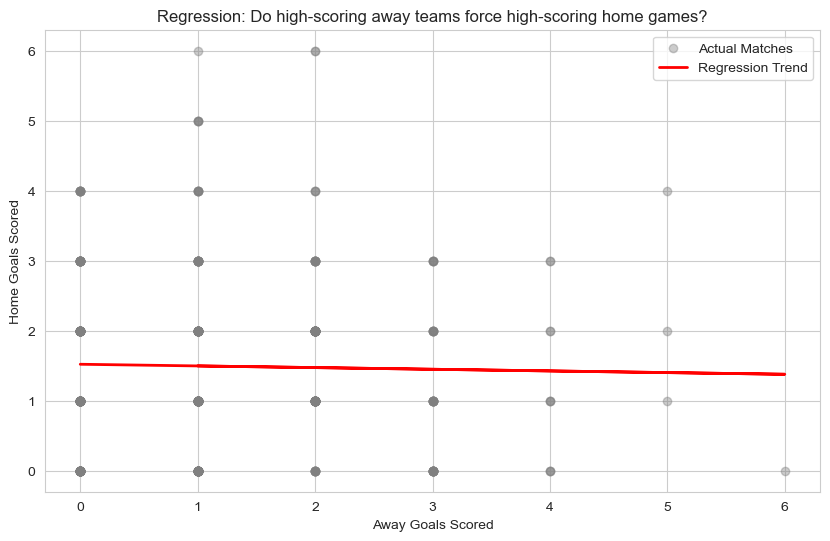

In [28]:

# (3) Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='gray', alpha=0.4, label='Actual Matches')
plt.plot(X, y_pred, color='red', linewidth=2, label='Regression Trend')
plt.xlabel("Away Goals Scored")
plt.ylabel("Home Goals Scored")
plt.title("Regression: Do high-scoring away teams force high-scoring home games?")
plt.legend()
plt.show()

**The scatter plot illustrates the weak relationship between the number of away goals and the number of home goals**, illustrating that football goal scoring is highly random, and that simple linear models have little to no predictive ability in relation to this area of study.

### Interpretation of Scatter Plot

The scatter plot displays a large amount of variability in the number of home goals across all possible values of away goals. There is also no obvious trend in either direction. The fitted linear regression line is essentially flat with a very slight negative slope, supporting the fact that the **relationship between the number of away goals and the number of home goals is extremely weak**.

These graphical representations support the very small R² that was calculated previously, demonstrating that the number of away goals has virtually **no predictive capability** in determining the number of home goals. As a practical matter, this implies that football game goal scoring is highly unpredictable, and that **the number of goals scored by the home team does not depend on the number of goals scored by the away team in a meaningful way**.

These findings reinforce the notion that **football goal scoring is largely driven by match-specific factors as opposed to being influenced by simple linear relationships between teams**.

With the home advantage established through statistical testing and the relationship between home and away goals determined through linear regression modeling, we proceed to analyze the season-long performance of the league champions (Leicester City) in Step 5.

---

## Secondary Question 3: What was the level of consistency in Leicester City's goal-scoring performance throughout the course of the 2015-2016 Premier League season?

The goal-scoring consistency of the league champions (Leicester City) throughout the season is analyzed through a time-series analysis of the number of goals scored by Leicester City across the season, using match-by-match data and a rolling average to evaluate whether Leicester City's goal-scoring performance was consistent over the long-term (across the entire season) or whether their goal-scoring performance was inconsistent and based upon isolated instances of high-scoring performances.

This secondary question will be addressed in Step 5.


## Step 5: Team Form Analysis (Champion)

In this final analysis phase in step 5 where we will look at the league champion (Leicester City):

- Select only those matches in which the champion team played.
- Determine how many goals were scored by the champion team in each of these selected matches.
- Find a five-match rolling average of the number of goals scored by the champion team in order to evaluate the stability of their “form” (i.e., scoring pattern).
- Plot the number of goals scored by the champion team in each game during the entire season along with their five-game rolling average of goals scored to visually examine how consistent their performance was.

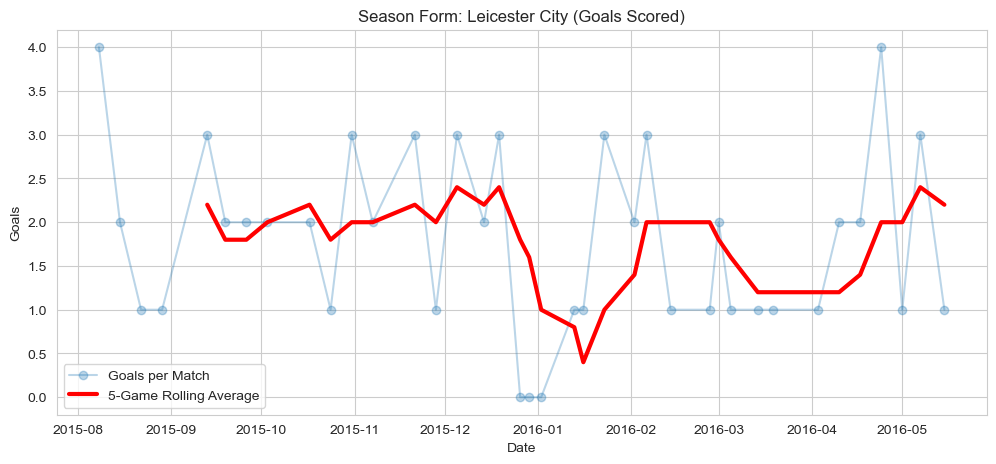

In [29]:
# Champion Team Form Analysis 
champion = league_table.iloc[0]["Team"] 

# Filter matches involving the champion team
champ_matches = df[(df["home_team"] == champion) | (df["away_team"] == champion)].copy()
champ_matches = champ_matches.sort_values("date")

# Find out  goals scored by the champion team in each match
champ_matches["goals_scored"] = np.where(
    champ_matches["home_team"] == champion, 
    champ_matches["home_goals"], 
    champ_matches["away_goals"]
)

# Calculate a 5-game rolling average
champ_matches["form"] = champ_matches["goals_scored"].rolling(window=5).mean()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(champ_matches["date"], champ_matches["goals_scored"], marker='o', alpha=0.3, label="Goals per Match")
plt.plot(champ_matches["date"], champ_matches["form"], color='red', linewidth=3, label="5-Game Rolling Average")
plt.title(f"Season Form: {champion} (Goals Scored)")
plt.xlabel("Date")
plt.ylabel("Goals")
plt.legend()
plt.show()

### Final Insight: Consistent Performance Patterns and Relationship to Home Advantage

The **consistent performance** of Leicester City in terms of their average number of goals scored per match demonstrated that their title-winning performance was driven by **steady and reliable attacking output** rather than a string of unusually high-scoring games. Their consistent performance patterns also reinforce the previous finding that there is a **positive relationship between home advantage and consistent performance patterns**.

## Analysis of Step 5 (Champion Form)

The plot illustrates that Leicester City’s goals per match fluctuate throughout the season, but the **5-game rolling average remains relatively stable**. This suggests that Leicester were consistently scoring goals across the season rather than relying on a few exceptionally high-scoring matches to generate their title-winning momentum.

There are however some brief times when the five-game rolling average of goals scored drops slightly lower than others, but it rarely drops significantly lower for extended periods of time. It is therefore reasonable to suggest that the **consistent scoring output** of Leicester City contributed significantly to their ability to remain competitive for the majority of the season and ultimately win the championship.

## Project Summary

In this project we analysed match-level data from the 2015-2016 English Premier League season to create various visualizations and statistical outputs using Python (pandas, numpy, matplotlib, seaborn, scikit-learn). The original match-level data was obtained from an online JSON file, cleaned, and formatted into a structured format. Various new features were created (total goals, goal difference, and match points) to provide additional input for our analysis.

The initial exploratory data analysis illustrated that most teams typically score between zero and two goals per match. Additionally, home and away goals are only weakly positively correlated; a correlation heatmap supported this conclusion. **Total goals were found to be strongly positively correlated with both home and away goals**; whereas **home and away goals were found to be virtually uncorrelated**.

Following aggregation of home and away match points, we were able to accurately reproduce the final league standings, and properly identify Leicester City as the 2015-2016 champions with 81 match points. A t-test comparison of the average number of home and away goals was performed and provided statistically significant evidence that **a scoring advantage is associated with playing at home**.

Next, we fit a linear regression model to determine if the number of away goals can predict the number of home goals. The extremely low R² value demonstrated that the **number of away goals has essentially no predictive capability regarding the number of home goals**, and thus the unpredictability of football scoring is largely confirmed.

Lastly, we analyzed the five-game rolling average of the number of goals scored by **Leicester City** to assess their performance stability throughout the season. Our analysis concluded that their **title winning performance was primarily due to their ability to consistently produce and convert scoring opportunities**, rather than having a few exceptionally high-scoring games.

## Limitations

This analysis is limited to using only match-level score data and does not incorporate expected goals, possession, shot volume, or shot quality data. Thus, the performance of teams is being evaluated based on final scores, and not on underlying probability of creating chances and dominating possession of the ball, which may obscure deeper trends in a team's performance.


## Future Research Directions

Future studies could expand on this research by:
- Examining home advantage over multiple seasons to compare changes in its effect over time.
- Including expected goals, shot data, and possession data to improve the accuracy of predictions.
- Comparing the performance of Leicester City during the 2015-2016 season with those of other title-winners in other leagues.